In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

OUT_PATH = '../figures/accuracy_comparison.png'

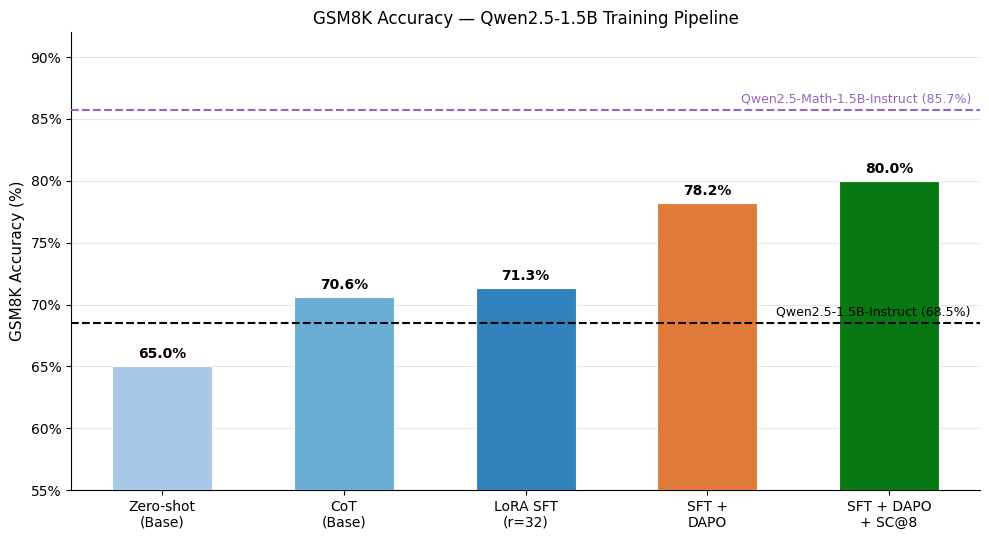

Saved to ../figures/accuracy_comparison.png


In [10]:
methods = [
    'Zero-shot\n(Base)',
    'CoT\n(Base)',
    'LoRA SFT\n(r=32)',
    'SFT +\nDAPO',
    'SFT + DAPO\n+ SC@8',
]
accuracies = [65.0, 70.6, 71.3, 78.2, 80.0]

# Color gradient: lighter for early stages, darker for later
colors = ['#a8c8e8', '#6aaed6', '#3182bd', '#e07b39', "#087912"]

INSTRUCT_ACC  = 68.5
MATH_ACC      = 85.7

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.bar(methods, accuracies, color=colors, edgecolor='white',
              linewidth=0.8, width=0.55, zorder=3)

# Value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{acc:.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Reference dashed lines
x_min, x_max = -0.5, len(methods) - 0.5

ax.hlines(INSTRUCT_ACC, x_min, x_max,
          colors="#000000", linestyles='--', linewidth=1.5, zorder=4)
ax.text(x_max - 0.05, INSTRUCT_ACC + 0.4,
        f'Qwen2.5-1.5B-Instruct ({INSTRUCT_ACC}%)',
        ha='right', va='bottom', fontsize=9, color="#000000")

ax.hlines(MATH_ACC, x_min, x_max,
          colors='#9467bd', linestyles='--', linewidth=1.5, zorder=4)
ax.text(x_max - 0.05, MATH_ACC + 0.4,
        f'Qwen2.5-Math-1.5B-Instruct ({MATH_ACC}%)',
        ha='right', va='bottom', fontsize=9, color='#9467bd')

ax.set_ylabel('GSM8K Accuracy (%)', fontsize=11)
ax.set_title('GSM8K Accuracy — Qwen2.5-1.5B Training Pipeline', fontsize=12)
ax.set_ylim(55, 92)
ax.set_xlim(x_min, x_max)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {OUT_PATH}')